In [38]:
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import exponential_kernel

# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation_torch import generate_location_and_partitions, generate_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1

B = 100  # Number of regions
sigmasq_true = 5
tausq_true = 0.5
nu_true = 0.5

phi_list = [2.0, 4.0, 6.0, 8.0]
SNR_list = torch.logspace(-5, -2, steps=6)  # 1e-3 to 1e1
phi_true= 2
n_i=6

N = B * n_i
torch.manual_seed(5556)  # Set a seed for reproducibility
perm_x = torch.randperm(n_i)
perm_s = torch.randperm(n_i)

# Convert permutations into permutation matrices
perm_matrix_s = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_s[torch.arange(n_i), perm_s] = 1

perm_matrix_x = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_x[torch.arange(n_i), perm_x] = 1
torch.manual_seed(1)
s, region_assignments = generate_location_and_partitions(B, n_i, d_min=1)
Sigma = sigmasq_true * exponential_kernel(s, s, phi_true)
Sigma += tausq_true * torch.eye(s.shape[0], device=device)
eigvals = torch.linalg.eigvalsh(Sigma)
lambda_max = torch.max(eigvals).item()
kappa = torch.linalg.cond(Sigma).item()
kappa


87.89456176757812

/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_21084/1256056113.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(s)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_21084/1256056113.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  region_assignments = torch.tensor(region_assignments)


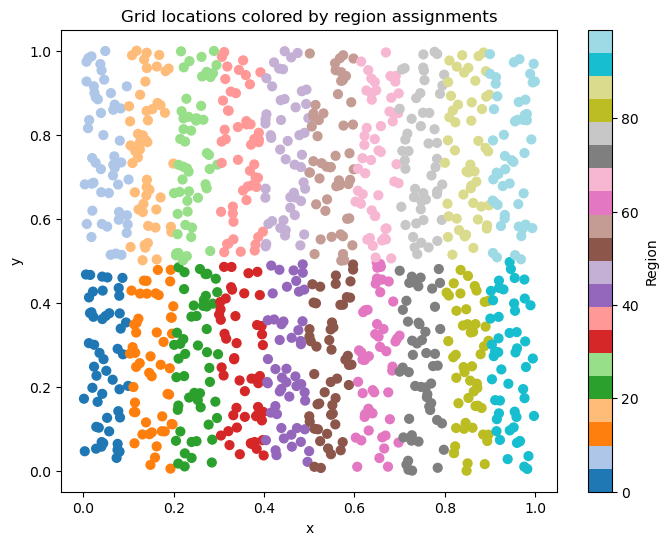

d_min: 0.0004, d_max: 1.3786
Region 0: d_min = 0.0045, d_max = 0.0771
Region 1: d_min = 0.0059, d_max = 0.1032
Region 2: d_min = 0.0174, d_max = 0.1235
Region 3: d_min = 0.0038, d_max = 0.0983
Region 4: d_min = 0.0093, d_max = 0.0895
Region 5: d_min = 0.0116, d_max = 0.1063
Region 6: d_min = 0.0046, d_max = 0.1189
Region 7: d_min = 0.0084, d_max = 0.0984
Region 8: d_min = 0.0068, d_max = 0.0975
Region 9: d_min = 0.0079, d_max = 0.1083
Region 10: d_min = 0.0066, d_max = 0.1024
Region 11: d_min = 0.0021, d_max = 0.1241
Region 12: d_min = 0.0098, d_max = 0.0964
Region 13: d_min = 0.0020, d_max = 0.1033
Region 14: d_min = 0.0059, d_max = 0.0999
Region 15: d_min = 0.0065, d_max = 0.1014
Region 16: d_min = 0.0092, d_max = 0.0772
Region 17: d_min = 0.0051, d_max = 0.1041
Region 18: d_min = 0.0081, d_max = 0.0933
Region 19: d_min = 0.0089, d_max = 0.0869
Region 20: d_min = 0.0110, d_max = 0.1015
Region 21: d_min = 0.0103, d_max = 0.0906
Region 22: d_min = 0.0174, d_max = 0.1185
Region 23: d_mi

In [32]:
from scipy.spatial.distance import pdist


import matplotlib.pyplot as plt

s = torch.tensor(s)
region_assignments = torch.tensor(region_assignments)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(s[:, 0], s[:, 1], c=region_assignments, cmap='tab20', s=40)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grid locations colored by region assignments')
plt.colorbar(scatter, label='Region')
plt.show()

# Compute pairwise distances between all locations
distances = pdist(s.numpy())
d_min = np.min(distances)
d_max = np.max(distances)
print(f"d_min: {d_min:.4f}, d_max: {d_max:.4f}")
unique_regions = torch.unique(region_assignments)
for region in unique_regions:
    indices = (region_assignments == region).nonzero(as_tuple=True)[0]
    s_region = s[indices]
    if s_region.shape[0] > 1:
        distances_region = pdist(s_region.numpy())
        d_min_region = np.min(distances_region)
        d_max_region = np.max(distances_region)
        print(f"Region {region.item()}: d_min = {d_min_region:.4f}, d_max = {d_max_region:.4f}")
    else:
        print(f"Region {region.item()}: only one point, no distances to compute.")


In [39]:
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import exponential_kernel

# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation_torch import generate_location_and_partitions, generate_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1

B_list = [49, 81, 100, 121, 144]  # Number of regions
sigmasq_true = 5
tausq_true = 0.5
nu_true = 0.5

phi_list = [2.0]
#SNR_list = torch.logspace(-5, -2, steps=6)  # 1e-3 to 1e1
SNR_list= [1]

def compute_beta(s, sigmasq, phi, tausq, snr):
    Sigma = sigmasq * exponential_kernel(s, s, phi)
    Sigma += tausq * torch.eye(s.shape[0], device=device)
    eigvals = torch.linalg.eigvalsh(Sigma)
    lambda_max = torch.max(eigvals).item()
    kappa = torch.linalg.cond(Sigma).item()
    beta_sq = snr * lambda_max * (kappa ** 2)
    return np.sqrt(beta_sq)

# Data generation
for n_i in [6]:
    for B in B_list:
        N = B * n_i
        torch.manual_seed(5556)  # Set a seed for reproducibility
        perm_x = torch.randperm(n_i)
        perm_s = torch.randperm(n_i)

        # Convert permutations into permutation matrices
        perm_matrix_s = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
        perm_matrix_s[torch.arange(n_i), perm_s] = 1

        perm_matrix_x = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
        perm_matrix_x[torch.arange(n_i), perm_x] = 1
        torch.manual_seed(1)
        s, region_assignments = generate_location_and_partitions(B, n_i)

        for phi_true in phi_list:
            for snr in SNR_list:
                for seed_generate in range(1, 101):
                    x = torch.rand(N, 1)
                    s_tensor = torch.tensor(s, dtype=torch.float32, device=device)

                    #beta_true = compute_beta(s_tensor, sigmasq_true, phi_true, tausq_true, snr)
                    beta_true = 8
                    print(f"phi = {phi_true:.2f}, SNR = {snr:.1e}, beta = {beta_true:.4f}")

                    torch.manual_seed(seed_generate)
                    y, w, e = generate_data(s, x, sigmasq_true, phi_true, beta_true, tausq_true, seed=seed_generate)

                    # Convert to tensors and send to device
                    y = torch.tensor(y, dtype=torch.float32, device=device)
                    x = torch.tensor(x, dtype=torch.float32, device=device)
                    w = torch.tensor(w, dtype=torch.float32, device=device)
                    e = torch.tensor(e, dtype=torch.float32, device=device)
                    s = torch.tensor(s, dtype=torch.float32, device=device)
                    region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)
                    unique_regions = torch.unique(region_assignments)

                    x_jumbled_within_regions = torch.zeros_like(x)
                    s_jumbled_within_regions = torch.zeros_like(s)

                    for i, region in enumerate(unique_regions):
                        indices = torch.where(region_assignments == region)[0]
                        x_jumbled_within_regions[indices] = x[indices[perm_x]]
                        s_jumbled_within_regions[indices] = s[indices[perm_s]]

                    output_dir = os.path.join('..', 'data', 'vary_B', f"B_{B}_n_{n_i}", f"phi_{phi_true}_snr_{snr:.1e}")
                    os.makedirs(output_dir, exist_ok=True)

                    output_file = os.path.join(output_dir, f"data_seed_{seed_generate}.pt")
                    torch.save({
                        'y': y,
                        'region_assignments': region_assignments,
                        'x': x,
                        'w': w,
                        'e': e,
                        's': s,
                        'x_jumbled_within_regions': x_jumbled_within_regions,
                        's_jumbled_within_regions': s_jumbled_within_regions,
                        'perm_matrix_x': perm_matrix_x,
                        'perm_matrix_s': perm_matrix_s,
                        'sigmasq_true': sigmasq_true,
                        'phi_true': phi_true,
                        'beta_true': beta_true,
                        'nu_true': nu_true,
                        'tausq_true': tausq_true,
                        'snr': snr
                    }, output_file)

                    print(f"Data saved to {output_file}")


/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_21084/2665433243.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_tensor = torch.tensor(s, dtype=torch.float32, device=device)


phi = 2.00, SNR = 1.0e+00, beta = 8.0000


/Users/debangandey/Documents/GitHub/SpatialReg-Unlinked/data/generation_torch.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(torch.distributions.MultivariateNormal(torch.zeros(N), K).sample())
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_21084/2665433243.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_21084/2665433243.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tens

Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_1.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_2.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_3.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_4.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_5.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_6.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_7.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_8.pt
phi = 2.00, SNR = 1.0e+00, beta = 8.0000
Data saved to ../data/vary_B/B_49_n_6/phi_2.0_snr_1.0e+00/data_seed_9.pt
phi = 2.00, SNR